## Tomato Pollination: Pepper 0

In [1]:
# def parse_obj_to_input_with_commas(obj_filename):
#     nodes = []
#     edges = []

#     # Read obj file
#     with open(obj_filename, "r") as f:
#         for line in f:
#             parts = line.strip().split()
#             if not parts:
#                 continue
#             if parts[0] == "v":  # Node line
#                 nodes.append([float(x) for x in parts[1:4]])
#             elif parts[0] == "l":  # Edge line
#                 edges.append([int(x) for x in parts[1:]])

#     # Write to input.txt with commas
#     out_filename=obj_filename.replace(".obj", ".txt")
#     with open(out_filename, "w") as f:
#         f.write("*Nodes\n")
#         for (x, y, z) in nodes:
#             f.write(f"{x}, {y}, {z}\n")

#         f.write("*Edges\n")
#         for (n1, n2) in edges:
#             f.write(f"{n1}, {n2}\n")

#     return out_filename

# # Run for all files in the directory
# directory = "../tests/resources/tomato_pollination/plants/"
# import os
# for filename in os.listdir(directory):
#     if filename.endswith(".obj"):
#         parse_obj_to_input_with_commas(os.path.join(directory, filename))



In [2]:
import numpy as np
import dismech
import os

plant_name = "pepper0"

position = "2"

geom = dismech.GeomParams(
    rod_r0=0.03,
    shell_h=0.0,
)

material = dismech.Material(density=1100,
                            youngs_rod=2.16e7,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dyn_sim = dismech.SimParams(static_sim=True,
                                  two_d_sim=True,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=50,
                                  total_time=5,
                                  plot_step=100,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2
                                  )

env = dismech.Environment()
# env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('damping', eta=100)

input_txt = os.path.join('../tests/resources/tomato_pollination/plants/', f"{plant_name}.txt")
geo = dismech.Geometry.from_txt(input_txt)

robot = dismech.SoftRobot(geom, material, geo, dyn_sim, env)

### Move the stem: Moving BC

In [3]:
# # --- pick the main grip node robustly ---
# grasping_point = np.array([
#       1.1120794,
#       0.0663341,
#       0.3889156
#     ])

main_grip = [47]

print("Main grip node:", main_grip)
#82

# other_grip_nodes_below = np.array([1, 5, 8, 13], dtype=int)
# other_grip_nodes_above = np.array([57, 47, 44, 33, 28, 21], dtype=int)
other_grip_nodes_below = []
other_grip_nodes_above = []

Main grip node: [47]


In [4]:
base_nodes = np.where((robot.state.q[robot.node_dof_indices].reshape(-1, 3)[:, 2]) < 0.22)[0] # fixed base
# Fix only main_grip and base nodes
robot = robot.fix_nodes(np.unique(np.r_[main_grip, base_nodes]))

In [5]:
print(np.unique(np.r_[main_grip, base_nodes]))

[ 0  1  2  3 47]


In [6]:
# ----- once, before simulation -----
all_grip_nodes = np.r_[main_grip, other_grip_nodes_below, other_grip_nodes_above].astype(int)

xyz0 = robot.state.q[robot.node_dof_indices].reshape(-1, 3).copy()
x0 = xyz0[all_grip_nodes, 0].copy()          # initial x of all prescribed nodes
prev_target_x = x0.copy()                     # last absolute target (starts at initial)

# (Optional) precompute amplitude scalings from *initial* geometry
def build_amps_from_xyz0(xyz0, main_grip, all_grip_nodes, A_main):
    amps = np.empty(all_grip_nodes.size, float)
    amps[0] = A_main  # main_grip
    # below group
    below = np.array(other_grip_nodes_below, dtype=int)
    if below.size:
        ref = below[0]
        L = max(np.linalg.norm(xyz0[main_grip]-xyz0[ref]), 1e-12)
        for j, node in enumerate(below, start=1):  # start=1 because 0 is main_grip
            amps[j] = A_main * (np.linalg.norm(xyz0[ref]-xyz0[node]) / L)
    # above group
    above = np.array(other_grip_nodes_above, dtype=int)
    if above.size:
        ref = above[0]
        offset = 1 + below.size
        L = max(np.linalg.norm(xyz0[main_grip]-xyz0[ref]), 1e-12)
        for j, node in enumerate(above, start=offset):
            amps[j] = A_main * (np.linalg.norm(xyz0[ref]-xyz0[node]) / L)
    return amps

A_main = 0.32722e-2  # m at main_grip
freq   = 1    # Hz
# amps   = build_amps_from_xyz0(xyz0, main_grip, all_grip_nodes, A_main)
amps   = np.array([A_main for _ in all_grip_nodes])
print("Amplitudes (m):", amps)

def shake_distributed(robot, t: float):
    # absolute target centered at initial pose
    target_x = x0 + amps * np.sin(2*np.pi*freq*t)

    # INCREMENT ONLY: avoids velocity spikes and keeps symmetry
    delta_x = target_x - prev_target_x
    prev_target_x[:] = target_x

    return robot.move_nodes(all_grip_nodes, delta_x.reshape(-1,1).flatten(), axis=0)

print("grasping points:", all_grip_nodes)

Amplitudes (m): [0.0032722]
grasping points: [47]


In [7]:
stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = shake_distributed

### Simulate

In [8]:
# simulate
robots = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])

iter: 1, error: 7922.936
iter: 2, error: 130.032
current_time:  0.01
iter: 1, error: 7891.748
iter: 2, error: 128.788
current_time:  0.02
iter: 1, error: 7829.530
iter: 2, error: 126.757
current_time:  0.03
iter: 1, error: 7736.197
iter: 2, error: 123.743
current_time:  0.04
iter: 1, error: 7612.141
iter: 2, error: 119.783
current_time:  0.05
iter: 1, error: 7457.880
iter: 2, error: 114.942
current_time:  0.06
iter: 1, error: 7274.054
iter: 2, error: 109.298
current_time:  0.07
iter: 1, error: 7061.424
iter: 2, error: 102.945
current_time:  0.08
iter: 1, error: 6820.864
iter: 2, error: 95.986
current_time:  0.09
iter: 1, error: 6553.361
iter: 2, error: 88.536
current_time:  0.1
iter: 1, error: 6260.004
iter: 2, error: 80.717
current_time:  0.11
iter: 1, error: 5941.984
iter: 2, error: 72.655
current_time:  0.12
iter: 1, error: 5600.584
iter: 2, error: 64.480
current_time:  0.13
iter: 1, error: 5237.175
iter: 2, error: 56.324
current_time:  0.14
iter: 1, error: 4853.210
iter: 2, error: 

### Plotting

In [9]:
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(title=plant_name, plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t, qs , options)
fig.show()

51


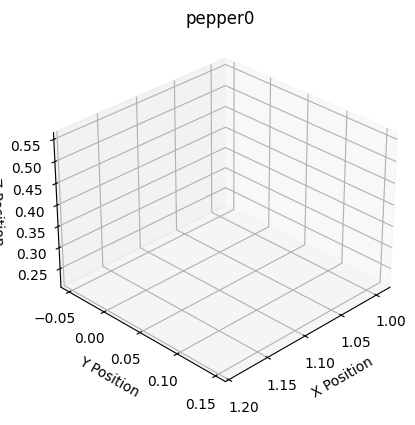

In [10]:
# save gif
ani = dismech.get_animation(robot, t, qs, options)
save_path = os.path.join("tomato_results", f"{plant_name}_{position}.gif")
ani.save(save_path)

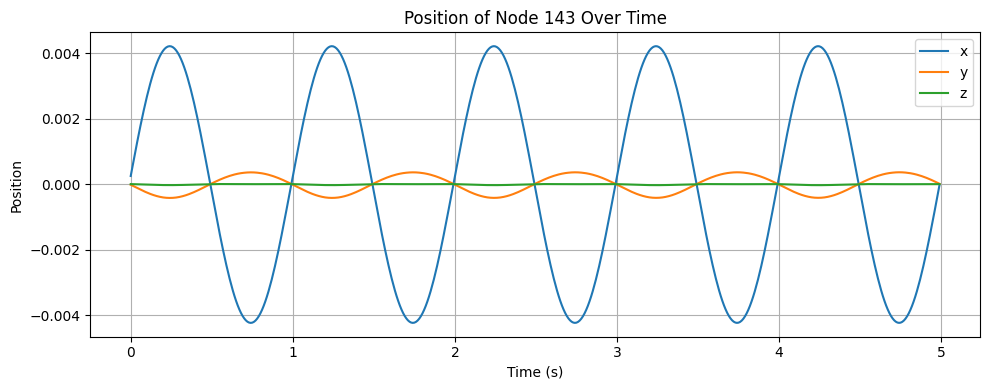

In [11]:
# plot the trajectory of the flower location
flower_node = 143  # pick a node at the flower
# flower_node = main_grip  # pick a node at the flower

import matplotlib.pyplot as plt

# Extract the DOF indices (x, y, z) of the node you want to track
flower_node_dofs = robot.map_node_to_dof(flower_node)  # e.g., [ix, iy, iz]

# Extract position of that node across all timesteps
logged = qs[:, flower_node_dofs].squeeze()  # shape (n_timesteps, 3)

# remove value at t=0
logged -= robot.nodes[flower_node]

# Plot x, y, z over time
t = np.arange(qs.shape[0]) * robot.sim_params.dt

plt.figure(figsize=(10, 4))
plt.plot(t, logged[:, 0], label='x')
plt.plot(t, logged[:, 1], label='y')
plt.plot(t, logged[:, 2], label='z')
plt.xlabel('Time (s)')
plt.ylabel('Position')
plt.title(f'Position of Node {flower_node} Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
import numpy as np
from scipy.signal import hilbert, detrend, find_peaks

def avg_cycle_amplitude_hilbert(x: np.ndarray) -> float:
    """
    Robust average oscillation amplitude using the analytic-signal envelope.
    Returns the median envelope value (less sensitive to outliers).
    """
    x = np.asarray(x).ravel()
    x = detrend(x)  # remove slow drift
    envelope = np.abs(hilbert(x))
    # Use median to resist occasional spikes; mean is also fine.
    return float(np.median(envelope))
# amplitude of flower node motion
amp_x_flower_hilbert = avg_cycle_amplitude_hilbert(logged[:, 0]) # hilbert-based amplitude
amp_x_flower_peak = (np.max(logged[:, 0]) - np.min(logged[:, 0])) / 2.0 # peak-to-peak amplitude
print(f"Amplitude of flower node {flower_node} motion in x (peak-to-peak): {amp_x_flower_peak:.4f} m")
print(f"Amplitude of flower node {flower_node} motion in x (hilbert): {amp_x_flower_hilbert:.4f} m")

Amplitude of flower node 143 motion in x (peak-to-peak): 0.0042 m
Amplitude of flower node 143 motion in x (hilbert): 0.0042 m


### Save data for rendering

In [13]:
# from dismech.logging import logDataForRendering
# from dismech.logging import export_rod_shell_data, export_parachute_data

# rod_data, shell_data = logDataForRendering(qs, t.reshape(-1, 1), robot, len(t), robot.sim_params.static_sim, robot.map_node_to_dof, log_step=10)

# js_file = os.path.join("tomato_results", f"{plant_name}_{position}.js")

# export_parachute_data(qs, geo.rod_edges, robot,
#                           rod_js=js_file,
#                           scaleFactor=100)

### Estimated values of parameters

In [14]:
# L = 0.292 # m
# r0 = 0.0059 # m

# delta = 0.054 # m # delta = PL^3/(3EI)
# P = 0.02*9.81 # N

# K = P/delta # effective stiffness

# I = np.pi * r0**4 / 4
# E = P*(L**3) / (3 * I * delta)

# print("E:", E)

# f = 1.38 # Hz
# TP = 0.725 # s

# omega = 2 * np.pi * f
# m_eff = K / omega**2
# print("m_eff:", m_eff)

# # estimate density
# V = np.pi * r0**2 * L
# rho = m_eff / V
# print("rho:", rho)